**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


**Parameters for data preprocessing**

In [2]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000                                                             

### Filepaths MFCC ###
# Training
data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\wav2vec_updated_segment_outputs\\wav2vec_updated_train'

# Development/Validation
dev_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\wav2vec_updated_segment_outputs\\wav2vec_updated_dev'


**Preprocessing of training data** 

In [3]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    feature = feature.squeeze()  # Remove all dimensions of size 1
    features_list.append(feature)
    labels_list.append(label)

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[[ 0.2179,  0.2016,  0.2267,  ...,  0.2306, -0.0233,  0.0987],
         [ 0.1788,  0.1425,  0.2675,  ...,  0.2464,  0.2301,  0.2278],
         [ 0.3656,  0.3359,  0.5670,  ...,  0.3014,  0.1462,  0.0137],
         ...,
         [ 0.3845,  0.2889, -0.0598,  ...,  0.1136,  0.2145,  0.2654],
         [ 0.2444,  0.2425,  0.4008,  ..., -0.0131,  0.5016,  0.0374],
         [-0.1276, -0.1849,  0.0831,  ..., -0.1139, -0.4504, -0.1402]]])
Example of the features tensor([[ 0.1086, -0.1761,  0.0204,  ..., -0.1684, -0.0327,  0.1153],
        [ 0.1055,  0.0781,  0.1380,  ...,  0.0912,  0.0980,  0.1712],
        [-0.0072, -0.2081, -0.0685,  ..., -0.2056,  0.0992,  0.3457],
        ...,
        [-0.0120,  0.1379,  0.0172,  ...,  0.1149,  0.0341, -0.0904],
        [ 0.1835,  0.7901,  0.1871,  ...,  0.7964,  0.4689,  0.2707],
        [-0.2077, -0.3498, -0.2579,  ..., -0.3430, -0.1508,  0.0538]])
Example of the labels tensor([0, 1, 0,  ..., 0, 0, 0])
Features shape: torch

**Dataset inspection**

In [4]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([768, 199])
First sample values:
 tensor([[ 0.2179,  0.2016,  0.2267,  ...,  0.2306, -0.0233,  0.0987],
        [ 0.1788,  0.1425,  0.2675,  ...,  0.2464,  0.2301,  0.2278],
        [ 0.3656,  0.3359,  0.5670,  ...,  0.3014,  0.1462,  0.0137],
        ...,
        [ 0.3845,  0.2889, -0.0598,  ...,  0.1136,  0.2145,  0.2654],
        [ 0.2444,  0.2425,  0.4008,  ..., -0.0131,  0.5016,  0.0374],
        [-0.1276, -0.1849,  0.0831,  ..., -0.1139, -0.4504, -0.1402]])
Sample Labels:
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0])


**Testing the Data Loader**

In [5]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

768
torch.Size([25380, 768, 199])
Batch features shape: torch.Size([64, 768, 199])


**Preprocessing and loading the Development/Validation Set**

In [6]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_feature = dev_feature.squeeze()  # Remove all singleton dimensions
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[[ 0.2163,  0.1237,  0.1817,  ..., -0.2527, -0.0379,  0.3187],
         [ 0.1787,  0.1606,  0.1297,  ...,  0.1204,  0.2379,  0.1881],
         [ 0.5411,  0.3143,  0.6383,  ...,  0.2175,  0.5429,  0.3084],
         ...,
         [ 0.1882,  0.0776, -0.3284,  ...,  0.0031,  0.0859, -0.1588],
         [ 0.1518,  0.1275,  0.2240,  ...,  0.5583,  0.1032,  0.1054],
         [-0.0726, -0.1698,  0.1941,  ..., -0.2630,  0.0699,  0.0363]]])
Example of the features tensor([[ 0.1196,  0.0133,  0.1230,  ..., -0.0482, -0.1270,  0.0178],
        [ 0.2182,  0.2659,  0.1788,  ...,  0.2040,  0.1479,  0.2228],
        [ 0.2834,  0.1544,  0.0238,  ...,  0.1769,  0.0467,  0.2468],
        ...,
        [ 0.1267,  0.0636,  0.1781,  ...,  0.3439,  0.2887,  0.2354],
        [ 0.2908,  0.1587,  0.2291,  ...,  0.5277,  0.6573,  0.1525],
        [-0.0965, -0.3776, -0.3801,  ..., -0.2942, -0.3700,  0.1105]])
Example of the labels tensor([0, 0, 0,  ..., 0, 0, 0])
Features shape: torch

**Testing the Processed Dataloaders and Label Distribution**

In [7]:
print("Training features shape",features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([64, 768, 199]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Training labels shape torch.Size([64])
Development features shape: torch.Size([24844, 768, 199]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Development labels shape: torch.Size([24844])
Training label distribution: tensor([60,  4])
Validation label distribution: tensor([22296,  2548])


**Hyperparemeters**

In [16]:
hidden_dim = 256  # Number of neurons in the hidden layer
dropout_prob = 0.3  # Dropout probability

**Neural Network Model**

In [18]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob):
        super(SpoofDetectionModel, self).__init__()

        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=768, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)  # Batch Normalization
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)  # Batch Normalization
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1) # Added layer
        self.bn3 = nn.BatchNorm1d(128) # Batch Normalization
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)

        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 24, hidden_dim)  # Adjusted input size based on pooling
        self.fc2 = nn.Linear(hidden_dim, 64) # Added intermediate layer
        self.fc3 = nn.Linear(64, 1)  # Single output neuron for binary classification

        # Initialize weights
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)

    def forward(self, x):
        # Input x is already (batch_size, num_channels, sequence_length) for wav2vec: [batch, 768, 199]

        # Convolutional layers
        x = torch.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool(x)  # Output size: [batch, 32, 99]

        x = torch.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool(x)  # Output size: [batch, 64, 49]

        x = torch.relu(self.conv3(x)) # Added layer
        x = self.bn3(x)
        x = self.pool(x)  # Output size: [batch, 128, 24]

        x = self.dropout(x)  # Apply dropout after convolutional layers

        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)  # Output size: [batch, 128 * 24]

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x)) # Added intermediate layer
        x = self.fc3(x)  # Output layer: Sigmoid for binary classification

        return x

**Initializing the model**

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

**Calculate the weights proportion for weighted loss**

In [20]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.74% | Bonafide: 10.26%
Weight of class 0 (spoof): tensor(0.5571)
Weight of class 1 (bonafide): tensor(4.8752)
Weight tensor to be passed to the Loss Function tensor(4.8752)


C:\Users\fnobrega\AppData\Local\Temp\ipykernel_20928\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [21]:
criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [22]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 5  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



**Training Loop**

In [23]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
# Training loop
num_epochs = 100

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for LFCC -> old code, possibly for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    model.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}%")

    # Learning rate scheduling
    scheduler.step(avg_loss_val)

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        torch.save(model.state_dict(), 'wav2vec_best_model.pth')
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break



Epoch [1/100] | Train Loss: 0.4004, Acc: 89.50% | Val Loss: 0.2380, Acc: 97.07% | Val EER: 4.90%
Epoch [2/100] | Train Loss: 0.0815, Acc: 98.09% | Val Loss: 0.1587, Acc: 98.44% | Val EER: 2.95%
Epoch [3/100] | Train Loss: 0.0437, Acc: 99.01% | Val Loss: 0.1112, Acc: 98.98% | Val EER: 2.11%
Epoch [4/100] | Train Loss: 0.0263, Acc: 99.41% | Val Loss: 0.1558, Acc: 98.84% | Val EER: 2.43%
EER not improved. Patience counter: 1/5
Epoch [5/100] | Train Loss: 0.0200, Acc: 99.54% | Val Loss: 0.2238, Acc: 98.84% | Val EER: 1.65%
Epoch [6/100] | Train Loss: 0.0116, Acc: 99.75% | Val Loss: 0.1422, Acc: 99.14% | Val EER: 1.69%
EER not improved. Patience counter: 1/5
Epoch [7/100] | Train Loss: 0.0091, Acc: 99.76% | Val Loss: 0.1264, Acc: 99.32% | Val EER: 1.29%
Epoch [8/100] | Train Loss: 0.0042, Acc: 99.91% | Val Loss: 0.1436, Acc: 99.28% | Val EER: 1.29%
Epoch [9/100] | Train Loss: 0.0033, Acc: 99.95% | Val Loss: 0.1463, Acc: 99.28% | Val EER: 1.26%
Epoch [10/100] | Train Loss: 0.0019, Acc: 99.96

**Plotting the results**

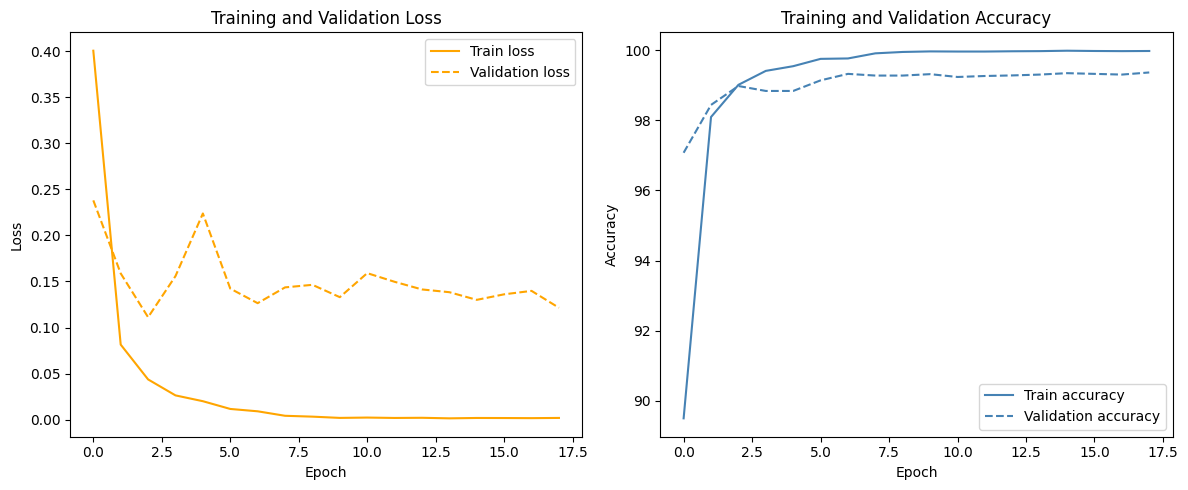

In [24]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model**

In [24]:
torch.save(model.state_dict(), 'wav2vec_v2_updated_model_deepfake_audio_detection_model.pth')

**Prepare Evaluation Dataset**

In [25]:
# Evaluation
eval_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\wav2vec_updated_segment_outputs\\wav2vec_updated_eval'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(eval_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

from torch.utils.data import Dataset, DataLoader

class EvalWav2VecDataset(Dataset):
    def __init__(self, file_list, data_dir):
        self.file_list = file_list
        self.data_dir = data_dir

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        file_path = os.path.join(self.data_dir, file_name)
        feature, label = torch.load(file_path)
        feature = feature.squeeze()
        return feature, label

eval_dataset = EvalWav2VecDataset(all_files, eval_data_dir)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[[ 0.1140, -0.2015, -0.2646,  ..., -0.1803,  0.2902,  0.1763],
         [ 0.1884,  0.2088,  0.1280,  ...,  0.1082,  0.1737,  0.2385],
         [ 0.5008,  0.1804,  0.0635,  ...,  0.2969,  0.1390,  0.3088],
         ...,
         [ 0.0499,  0.1330,  0.1452,  ...,  0.0784, -0.1779, -0.4521],
         [ 0.0692,  0.5403,  0.5490,  ...,  0.4080,  0.0821,  0.0760],
         [-0.2483, -0.4731, -0.4390,  ..., -0.3243,  0.0064, -0.1083]]])
The evaluation dataset has been successfully loaded into DataLoader.


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            total_loss += loss.item()
            predicted = (outputs > 0).float()
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(all_labels, all_scores)
    prob_threshold = expit(threshold)
    preds = (all_scores >= threshold).astype(int)
    
    # Calculate precision and recall
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(model, eval_dataLoader)


Evaluation Set:
Loss: 0.2438 | Accuracy: 96.39%
EER: 3.86% | Logit Threshold: -0.4477 | Prob Threshold: 0.3899
F1 Score: 0.8371
Precision: 0.7413
Recall: 0.9614
Predictions: [1]: 9539 | [0]: 61698
